### LASSO parameter range experiments, summary across all genes from Vogelstein et al. 2013

`scikit-learn` has two different implementations of logistic regression: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (using the `liblinear` coordinate descent optimizer) and [SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) (using stochastic gradient descent for optimization).

In this script we want to compare their performance and model selection dynamics across different levels of regularization, across the cancer genes in our gene set.

In [1]:
import os
import itertools as it

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

import pancancer_evaluation.config as cfg
import pancancer_evaluation.utilities.data_utilities as du
import pancancer_evaluation.utilities.analysis_utilities as au

%load_ext autoreload
%autoreload 2

In [2]:
ll_results_dir = os.path.join(
    cfg.repo_root,
    'results',
    'gene'
)

sgd_results_dir = os.path.join(
    cfg.repo_root,
    'results',
    'results_sgd_small',
    'gene'
)
lr_schedule = 'constant_search'

metric = 'aupr'

output_plots = True
output_plots_dir = os.path.join(
    cfg.repo_root, '01_stratified_classification', 'optimizers_plots'
)

### Get coefficient information for each lasso penalty

In [3]:
ll_coefs_df = []
ll_nz_coefs_df = []

# get coefficient info for training dataset specified above
for coef_info in au.generate_nonzero_coefficients_lasso_range(ll_results_dir,
                                                              nonzero_only=False):
    (gene,
     cancer_type,
     seed,
     lasso_param,
     coefs_list) = coef_info
    for fold_no, coefs in enumerate(coefs_list):
        ll_coefs_df.append(
            [gene, cancer_type, lasso_param, seed, fold_no,
             np.sum(np.absolute(list(zip(*coefs))[1]))+1]
        )
        ll_nz_coefs_df.append(
            [gene, cancer_type, lasso_param, seed, fold_no,
             len([1 for c in list(zip(*coefs))[1] if float(c) != 0.0])]
        )
       

In [4]:
ll_coefs_df = pd.DataFrame(
    ll_coefs_df,
    columns=['gene', 'signal', 'lasso_param', 'seed', 'fold', 'sum_coefs']
)
ll_coefs_df.lasso_param = ll_coefs_df.lasso_param.astype(float)

print(ll_coefs_df.gene.unique())
ll_coefs_df.head()

['ABCA13' 'AHNAK2' 'APC' 'APOB' 'ARID1A' 'BRAF' 'COL11A1' 'CSMD1' 'CSMD2'
 'CSMD3' 'DMD' 'DNAH11' 'DNAH5' 'DNAH7' 'DNAH8' 'DNAH9' 'FAT1' 'FAT3'
 'FAT4' 'FLG' 'GPR98' 'HMCN1' 'KMT2C' 'KMT2D' 'KRAS' 'LRP1B' 'LRP2'
 'MUC16' 'MUC17' 'MUC5B' 'NEB' 'OBSCN' 'PCDH15' 'PCLO' 'PIK3CA' 'PKHD1L1'
 'PTEN' 'RYR1' 'RYR2' 'RYR3' 'SPTA1' 'SSPO' 'SYNE1' 'SYNE2' 'TP53' 'TTN'
 'USH2A' 'XIRP2' 'XIST' 'ZFHX4']


,gene,signal,lasso_param,seed,fold,sum_coefs
0,ABCA13,classify,1.0,42,0,97.326485
1,ABCA13,classify,1.0,42,1,97.563157
2,ABCA13,classify,1.0,42,2,103.857486
3,ABCA13,classify,1.0,42,3,92.396786
4,AHNAK2,classify,1.0,42,0,101.829894


In [5]:
ll_nz_coefs_df = pd.DataFrame(
    ll_nz_coefs_df,
    columns=['gene', 'signal', 'lasso_param', 'seed', 'fold', 'nz_coefs']
)
ll_nz_coefs_df.lasso_param = ll_nz_coefs_df.lasso_param.astype(float)

print(ll_nz_coefs_df.gene.unique())
ll_nz_coefs_df.head()

['ABCA13' 'AHNAK2' 'APC' 'APOB' 'ARID1A' 'BRAF' 'COL11A1' 'CSMD1' 'CSMD2'
 'CSMD3' 'DMD' 'DNAH11' 'DNAH5' 'DNAH7' 'DNAH8' 'DNAH9' 'FAT1' 'FAT3'
 'FAT4' 'FLG' 'GPR98' 'HMCN1' 'KMT2C' 'KMT2D' 'KRAS' 'LRP1B' 'LRP2'
 'MUC16' 'MUC17' 'MUC5B' 'NEB' 'OBSCN' 'PCDH15' 'PCLO' 'PIK3CA' 'PKHD1L1'
 'PTEN' 'RYR1' 'RYR2' 'RYR3' 'SPTA1' 'SSPO' 'SYNE1' 'SYNE2' 'TP53' 'TTN'
 'USH2A' 'XIRP2' 'XIST' 'ZFHX4']


,gene,signal,lasso_param,seed,fold,nz_coefs
0,ABCA13,classify,1.0,42,0,771
1,ABCA13,classify,1.0,42,1,743
2,ABCA13,classify,1.0,42,2,809
3,ABCA13,classify,1.0,42,3,736
4,AHNAK2,classify,1.0,42,0,777


In [6]:
sgd_coefs_df = []
sgd_nz_coefs_df = []

# get coefficient info for training dataset specified above
for coef_info in au.generate_nonzero_coefficients_lasso_range(sgd_results_dir,
                                                              nonzero_only=False):
    (gene,
     cancer_type,
     seed,
     lasso_param,
     coefs_list) = coef_info
    for fold_no, coefs in enumerate(coefs_list):
        sgd_coefs_df.append(
            [gene, cancer_type, lasso_param, seed, fold_no,
             np.sum(np.absolute(list(zip(*coefs))[1]))+1]
        )
        sgd_nz_coefs_df.append(
            [gene, cancer_type, lasso_param, seed, fold_no,
             len([1 for c in list(zip(*coefs))[1] if float(c) != 0.0])]
        )

In [7]:
sgd_coefs_df = pd.DataFrame(
    sgd_coefs_df,
    columns=['gene', 'signal', 'lasso_param', 'seed', 'fold', 'sum_coefs']
)
sgd_coefs_df.lasso_param = sgd_coefs_df.lasso_param.astype(float)

print(sgd_coefs_df.gene.unique())
sgd_coefs_df.head()

['ABCA13' 'AHNAK2' 'APC' 'APOB' 'ARID1A' 'BRAF' 'COL11A1' 'CSMD1' 'CSMD2'
 'CSMD3' 'DMD' 'DNAH11' 'DNAH5' 'DNAH7' 'DNAH8' 'DNAH9' 'FAT1' 'FAT3'
 'FAT4' 'FLG' 'GPR98' 'HMCN1' 'KMT2C' 'KMT2D' 'KRAS' 'LRP1B' 'LRP2'
 'MUC16' 'MUC17' 'MUC5B' 'NEB' 'OBSCN' 'PCDH15' 'PCLO' 'PIK3CA' 'PKHD1L1'
 'PTEN' 'RYR1' 'RYR2' 'RYR3' 'SPTA1' 'SSPO' 'SYNE1' 'SYNE2' 'TP53' 'TTN'
 'USH2A' 'XIRP2' 'XIST' 'ZFHX4']


,gene,signal,lasso_param,seed,fold,sum_coefs
0,ABCA13,classify,1.0,42,0,1.00000
1,ABCA13,classify,1.0,42,1,26.84617
2,AHNAK2,classify,1.0,42,0,1.00000
3,AHNAK2,classify,1.0,42,1,1.00000
4,APC,classify,1.0,42,0,1.00000


In [8]:
sgd_nz_coefs_df = pd.DataFrame(
    sgd_nz_coefs_df,
    columns=['gene', 'signal', 'lasso_param', 'seed', 'fold', 'nz_coefs']
)
sgd_nz_coefs_df.lasso_param = sgd_nz_coefs_df.lasso_param.astype(float)

print(sgd_nz_coefs_df.gene.unique())
sgd_nz_coefs_df.head()

['ABCA13' 'AHNAK2' 'APC' 'APOB' 'ARID1A' 'BRAF' 'COL11A1' 'CSMD1' 'CSMD2'
 'CSMD3' 'DMD' 'DNAH11' 'DNAH5' 'DNAH7' 'DNAH8' 'DNAH9' 'FAT1' 'FAT3'
 'FAT4' 'FLG' 'GPR98' 'HMCN1' 'KMT2C' 'KMT2D' 'KRAS' 'LRP1B' 'LRP2'
 'MUC16' 'MUC17' 'MUC5B' 'NEB' 'OBSCN' 'PCDH15' 'PCLO' 'PIK3CA' 'PKHD1L1'
 'PTEN' 'RYR1' 'RYR2' 'RYR3' 'SPTA1' 'SSPO' 'SYNE1' 'SYNE2' 'TP53' 'TTN'
 'USH2A' 'XIRP2' 'XIST' 'ZFHX4']


,gene,signal,lasso_param,seed,fold,nz_coefs
0,ABCA13,classify,1.0,42,0,0
1,ABCA13,classify,1.0,42,1,8
2,AHNAK2,classify,1.0,42,0,0
3,AHNAK2,classify,1.0,42,1,0
4,APC,classify,1.0,42,0,0


### Get performance information for each lasso penalty

In [9]:
ll_perf_df = au.load_prediction_results_lasso_range(ll_results_dir,
                                                    'stratified')
ll_perf_df = (ll_perf_df
    .drop(columns=['holdout_cancer_type', 'experiment'])
    .copy()
)
ll_perf_df.lasso_param = ll_perf_df.lasso_param.astype(float)

print(ll_perf_df.shape)
print(ll_perf_df.gene.unique())
ll_perf_df.head()

(612, 8)
['ABCA13' 'AHNAK2' 'APC' 'APOB' 'ARID1A' 'BRAF' 'COL11A1' 'CSMD1' 'CSMD2'
 'CSMD3' 'DMD' 'DNAH11' 'DNAH5' 'DNAH7' 'DNAH8' 'DNAH9' 'FAT1' 'FAT3'
 'FAT4' 'FLG' 'GPR98' 'HMCN1' 'KMT2C' 'KMT2D' 'KRAS' 'LRP1B' 'LRP2'
 'MUC16' 'MUC17' 'MUC5B' 'NEB' 'OBSCN' 'PCDH15' 'PCLO' 'PIK3CA' 'PKHD1L1'
 'PTEN' 'RYR1' 'RYR2' 'RYR3' 'SPTA1' 'SSPO' 'SYNE1' 'SYNE2' 'TP53' 'TTN'
 'USH2A' 'XIRP2' 'XIST' 'ZFHX4']


,auroc,aupr,gene,signal,seed,data_type,fold,lasso_param
0,1.00000,1.00000,ABCA13,signal,42,train,0,1.0
1,0.51672,0.10497,ABCA13,signal,42,test,0,1.0
2,0.53831,0.11153,ABCA13,signal,42,cv,0,1.0
3,1.00000,1.00000,ABCA13,signal,42,train,1,1.0
4,0.53500,0.10242,ABCA13,signal,42,test,1,1.0


In [10]:
sgd_perf_df = au.load_prediction_results_lasso_range(sgd_results_dir,
                                                    'stratified')
sgd_perf_df = (sgd_perf_df
    .drop(columns=['holdout_cancer_type', 'experiment'])
    .copy()
)
sgd_perf_df.lasso_param = sgd_perf_df.lasso_param.astype(float)

print(sgd_perf_df.shape)
print(sgd_perf_df.gene.unique())
sgd_perf_df.head()

(300, 8)
['ABCA13' 'AHNAK2' 'APC' 'APOB' 'ARID1A' 'BRAF' 'COL11A1' 'CSMD1' 'CSMD2'
 'CSMD3' 'DMD' 'DNAH11' 'DNAH5' 'DNAH7' 'DNAH8' 'DNAH9' 'FAT1' 'FAT3'
 'FAT4' 'FLG' 'GPR98' 'HMCN1' 'KMT2C' 'KMT2D' 'KRAS' 'LRP1B' 'LRP2'
 'MUC16' 'MUC17' 'MUC5B' 'NEB' 'OBSCN' 'PCDH15' 'PCLO' 'PIK3CA' 'PKHD1L1'
 'PTEN' 'RYR1' 'RYR2' 'RYR3' 'SPTA1' 'SSPO' 'SYNE1' 'SYNE2' 'TP53' 'TTN'
 'USH2A' 'XIRP2' 'XIST' 'ZFHX4']


,auroc,aupr,gene,signal,seed,data_type,fold,lasso_param
0,0.50000,0.104450,ABCA13,signal,42,train,0,1.0
1,0.50000,0.096977,ABCA13,signal,42,test,0,1.0
2,0.50000,0.126710,ABCA13,signal,42,cv,0,1.0
3,0.50769,0.115690,ABCA13,signal,42,train,1,1.0
4,0.49716,0.112040,ABCA13,signal,42,test,1,1.0


In [11]:
# make sure gene sets are the same between optimizers
assert np.array_equal(
    sgd_perf_df.gene.sort_values().unique(),
    ll_perf_df.gene.sort_values().unique()
)

### Get "best" LASSO parameter and compare performance across all genes

Here, we'll just define the "best" model as the one with the highest validation set AUPR. We'll do this for each gene in the Vogelstein dataset, separately for each optimizer, and plot the distribution of AUPR differences between the two optimizers to give an idea of which one tends to be "better".

In [12]:
ll_top_df = []

# get top-performing lasso param for each gene,
# based on mean performance across seeds/folds
for gene in ll_perf_df.gene.unique():
    ll_mean_perf_df = (
      ll_perf_df[(ll_perf_df.gene == gene) &
                 (ll_perf_df.data_type == 'cv') &
                 (ll_perf_df.signal == 'signal')]
          .groupby(['lasso_param'])
          .agg(np.mean)
          .drop(columns=['seed', 'fold'])
          .rename(columns={'auroc': 'mean_auroc', 'aupr': 'mean_aupr'})
          .sort_values(by='mean_aupr', ascending=False)
          .reset_index()
    )
    ll_mean_perf_df['gene'] = gene
    ll_top_df.append(ll_mean_perf_df.iloc[[0], :])
    
ll_top_df = (
    pd.concat(ll_top_df)
      .set_index('gene')
)
print(ll_top_df.shape)
ll_top_df.head()

(50, 3)


,lasso_param,mean_auroc,mean_aupr
gene,,,
ABCA13,1.0,0.539085,0.120520
AHNAK2,1.0,0.572970,0.129933
APC,1.0,0.861847,0.748855
APOB,1.0,0.589897,0.147563
ARID1A,1.0,0.790127,0.482627


In [13]:
sgd_top_df = []

# get top-performing lasso param for each gene,
# based on mean performance across seeds/folds
for gene in sgd_perf_df.gene.unique():
    sgd_mean_perf_df = (
      sgd_perf_df[(sgd_perf_df.gene == gene) &
                  (sgd_perf_df.data_type == 'cv') &
                  (sgd_perf_df.signal == 'signal')]
          .groupby(['lasso_param'])
          .agg(np.mean)
          .drop(columns=['seed', 'fold'])
          .rename(columns={'auroc': 'mean_auroc', 'aupr': 'mean_aupr'})
          .sort_values(by='mean_aupr', ascending=False)
          .reset_index()
    )
    sgd_mean_perf_df['gene'] = gene
    sgd_top_df.append(sgd_mean_perf_df.iloc[[0], :])
    
sgd_top_df = (
    pd.concat(sgd_top_df)
      .set_index('gene')
)
print(sgd_top_df.shape)
sgd_top_df.head()

(50, 3)


,lasso_param,mean_auroc,mean_aupr
gene,,,
ABCA13,1.0,0.500285,0.118855
AHNAK2,1.0,0.500000,0.103340
APC,1.0,0.500000,0.201015
APOB,1.0,0.500000,0.112906
ARID1A,1.0,0.522915,0.211950


In [14]:
def get_top_optimizer_diff(gene):
    # TODO: put some of repeated code in functions
    ll_top_lasso_param = ll_top_df.loc[gene, 'lasso_param']
    sgd_top_lasso_param = sgd_top_df.loc[gene, 'lasso_param']
    
    ll_mean_test_perf_df = (
        ll_perf_df[(ll_perf_df.gene == gene) &
                   (ll_perf_df.data_type == 'test') &
                   (ll_perf_df.signal == 'signal')]
          .groupby(['lasso_param'])
          .agg(np.mean)
          .drop(columns=['seed', 'fold'])
          .rename(columns={'auroc': 'mean_auroc', 'aupr': 'mean_aupr'})
    )
    sgd_mean_test_perf_df = (
        sgd_perf_df[(sgd_perf_df.gene == gene) &
                    (sgd_perf_df.data_type == 'test') &
                    (sgd_perf_df.signal == 'signal')]
          .groupby(['lasso_param'])
          .agg(np.mean)
          .drop(columns=['seed', 'fold'])
          .rename(columns={'auroc': 'mean_auroc', 'aupr': 'mean_aupr'})
    )
    ll_sgd_diff = (
        ll_mean_test_perf_df.loc[ll_top_lasso_param, 'mean_aupr'] -
        sgd_mean_test_perf_df.loc[sgd_top_lasso_param, 'mean_aupr']
    )
    
    return [gene,
            ll_top_lasso_param,
            sgd_top_lasso_param,
            ll_sgd_diff]

print(get_top_optimizer_diff('PTEN'))

['PTEN', 1.0, 1.0, 0.55202]


In [15]:
all_top_optimizer_diff_df = []

for gene in ll_perf_df.gene.unique():
    all_top_optimizer_diff_df.append(
        get_top_optimizer_diff(gene)
    )
        
all_top_optimizer_diff_df = pd.DataFrame(
    all_top_optimizer_diff_df,
    columns=['gene', 'll_top_lasso_param',
             'sgd_top_lasso_param', 'll_sgd_diff']
)

all_top_optimizer_diff_df['best'] = 'liblinear'
all_top_optimizer_diff_df.loc[
    all_top_optimizer_diff_df.ll_sgd_diff < 0, 'best'
] = 'SGD'
# this probably won't happen but just in case
all_top_optimizer_diff_df.loc[
    all_top_optimizer_diff_df.ll_sgd_diff == 0, 'best'
] = 'equal'

print(all_top_optimizer_diff_df.best.value_counts())
all_top_optimizer_diff_df.head()

liblinear    50
Name: best, dtype: int64


,gene,ll_top_lasso_param,sgd_top_lasso_param,ll_sgd_diff,best
0,ABCA13,1.0,1.0,0.006959,liblinear
1,AHNAK2,1.0,1.0,0.037930,liblinear
2,APC,1.0,1.0,0.539340,liblinear
3,APOB,1.0,1.0,0.024130,liblinear
4,ARID1A,1.0,1.0,0.379295,liblinear


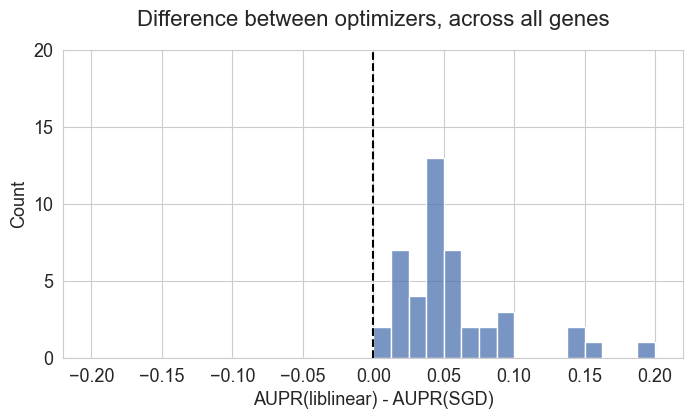

In [16]:
sns.set({'figure.figsize': (8, 4)})
sns.set_style('whitegrid')

if lr_schedule == 'optimal':
    # optimal LR is worse so needs larger positive range
    binrange = (-0.2, 0.45)
else:
    binrange = (-0.2, 0.2)
    
sns.histplot(all_top_optimizer_diff_df.ll_sgd_diff, binwidth=0.0125, binrange=binrange)
# plt.xlim(-0.15, 0.15)
if lr_schedule == 'constant_search':
    plt.title('Difference between optimizers, across all genes', size=16, y=1.05)
else:
    plt.title(f'Difference between optimizers, {lr_schedule} learning rate schedule', size=16, y=1.05)
plt.xlabel('AUPR(liblinear) - AUPR(SGD)', size=13)
plt.ylabel('Count', size=13)
plt.yticks(np.arange(0, 25, 5))
plt.gca().axvline(0, color='black', linestyle='--')
plt.gca().tick_params(axis='both', labelsize=13)

if output_plots:
    os.makedirs(output_plots_dir, exist_ok=True)
    plt.savefig(os.path.join(output_plots_dir, f'all_optimizers_diff_dist_{lr_schedule}.svg'), bbox_inches='tight')

In [17]:
all_top_optimizer_diff_df.sort_values(by='ll_sgd_diff', ascending=False).head(10)

,gene,ll_top_lasso_param,sgd_top_lasso_param,ll_sgd_diff,best
36,PTEN,1.0,1.0,0.552020,liblinear
2,APC,1.0,1.0,0.539340,liblinear
24,KRAS,1.0,1.0,0.419875,liblinear
5,BRAF,1.0,1.0,0.385560,liblinear
4,ARID1A,1.0,1.0,0.379295,liblinear
34,PIK3CA,1.0,1.0,0.265390,liblinear
44,TP53,1.0,1.0,0.198385,liblinear
45,TTN,1.0,1.0,0.153745,liblinear
23,KMT2D,1.0,1.0,0.147938,liblinear
27,MUC16,1.0,1.0,0.141030,liblinear


In [18]:
all_top_optimizer_diff_df.sort_values(by='ll_sgd_diff', ascending=True).head(10)

,gene,ll_top_lasso_param,sgd_top_lasso_param,ll_sgd_diff,best
0,ABCA13,1.0,1.0,0.006959,liblinear
15,DNAH9,1.0,1.0,0.010325,liblinear
21,HMCN1,1.0,1.0,0.020402,liblinear
10,DMD,1.0,1.0,0.020477,liblinear
14,DNAH8,1.0,1.0,0.020775,liblinear
26,LRP2,1.0,1.0,0.022173,liblinear
48,XIST,1.0,1.0,0.023228,liblinear
3,APOB,1.0,1.0,0.024130,liblinear
11,DNAH11,1.0,1.0,0.024297,liblinear
28,MUC17,1.0,1.0,0.032497,liblinear


### Compare feature selection with performance

In [19]:
ll_nz_coefs_perf_df = (ll_top_df
    .reset_index()
    .merge(ll_nz_coefs_df,
           on=['gene', 'lasso_param'])
    .drop(columns=['signal'])
)
ll_nz_coefs_perf_df['optimizer'] = 'liblinear'

print(ll_nz_coefs_perf_df.shape)
ll_nz_coefs_perf_df.head()

(204, 8)


,gene,lasso_param,mean_auroc,mean_aupr,seed,fold,nz_coefs,optimizer
0,ABCA13,1.0,0.539085,0.120520,42,0,771,liblinear
1,ABCA13,1.0,0.539085,0.120520,42,1,743,liblinear
2,ABCA13,1.0,0.539085,0.120520,42,2,809,liblinear
3,ABCA13,1.0,0.539085,0.120520,42,3,736,liblinear
4,AHNAK2,1.0,0.572970,0.129933,42,0,777,liblinear


In [20]:
sgd_nz_coefs_perf_df = (sgd_top_df
    .reset_index()
    .merge(sgd_nz_coefs_df,
           on=['gene', 'lasso_param'])
    .drop(columns=['signal'])
)
sgd_nz_coefs_perf_df['optimizer'] = 'SGD'

print(sgd_nz_coefs_perf_df.shape)
sgd_nz_coefs_perf_df.head()

(100, 8)


,gene,lasso_param,mean_auroc,mean_aupr,seed,fold,nz_coefs,optimizer
0,ABCA13,1.0,0.500285,0.118855,42,0,0,SGD
1,ABCA13,1.0,0.500285,0.118855,42,1,8,SGD
2,AHNAK2,1.0,0.500000,0.103340,42,0,0,SGD
3,AHNAK2,1.0,0.500000,0.103340,42,1,0,SGD
4,APC,1.0,0.500000,0.201015,42,0,0,SGD


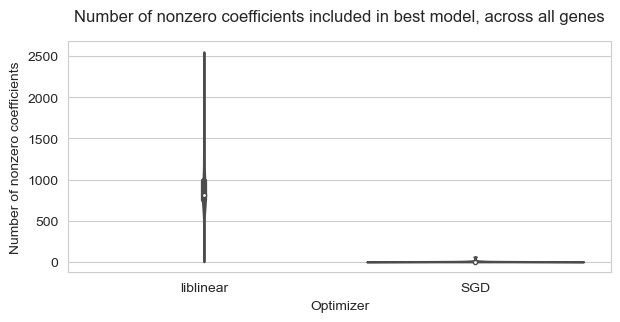

In [21]:
sns.set({'figure.figsize': (7, 3)})
sns.set_style('whitegrid')

nz_coefs_perf_df = pd.concat((ll_nz_coefs_perf_df, sgd_nz_coefs_perf_df))
sns.violinplot(data=nz_coefs_perf_df, x='optimizer', y='nz_coefs', cut=0)
plt.title('Number of nonzero coefficients included in best model, across all genes', y=1.05)
plt.xlabel('Optimizer')
plt.ylabel('Number of nonzero coefficients')

if output_plots:
    plt.savefig(os.path.join(output_plots_dir, f'all_optimizers_nz_coef_count_dist_{lr_schedule}.svg'), bbox_inches='tight')

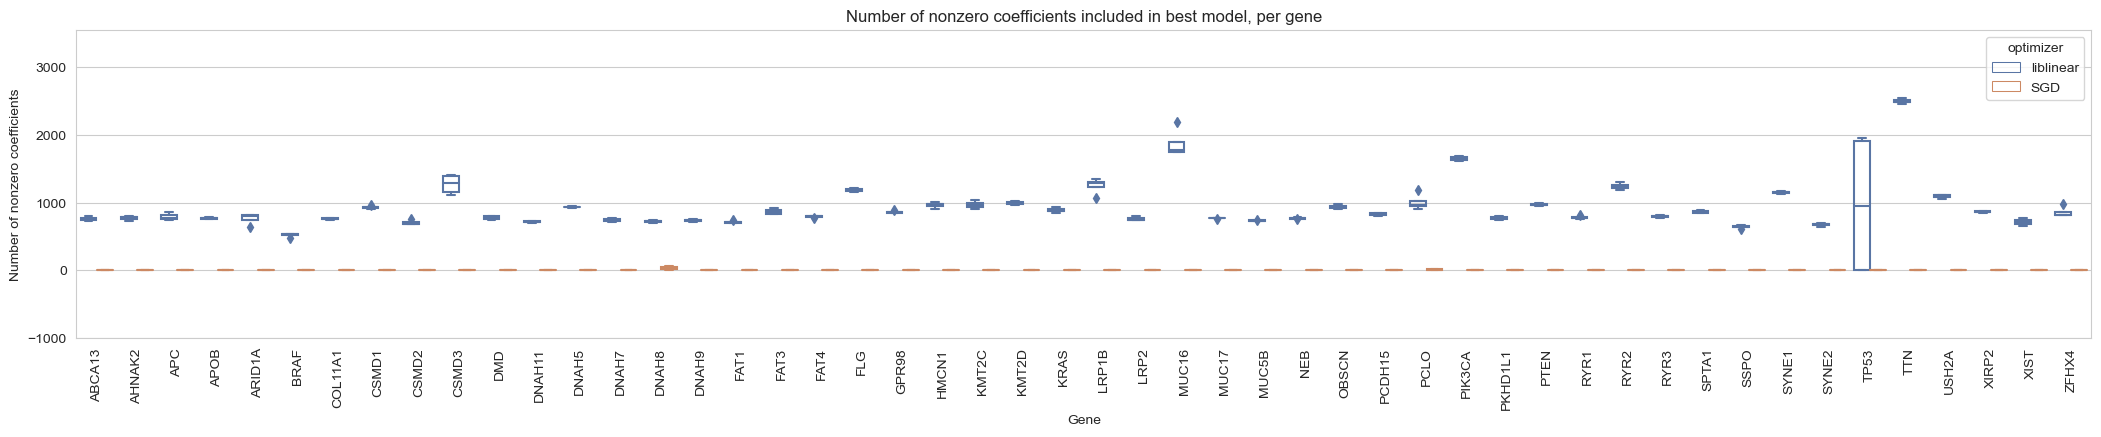

In [22]:
import matplotlib.patches
sns.set({'figure.figsize': (26, 4)})
sns.set_style('whitegrid')

sns.boxplot(data=nz_coefs_perf_df.sort_values(by='gene'),
            x='gene', y='nz_coefs', hue='optimizer')
plt.title('Number of nonzero coefficients included in best model, per gene')
plt.xlabel('Gene')
plt.xticks(rotation=90)
plt.ylabel('Number of nonzero coefficients')
plt.ylim(-1000, nz_coefs_perf_df.nz_coefs.max()+1000)

# color the boxplot lines/edges rather than the box fill
# this makes it easier to discern colors at the extremes; i.e. very many or few nonzero coefs
# https://stackoverflow.com/a/72333641
def color_boxes(ax):
    box_patches = [patch for patch in ax.patches if type(patch) == matplotlib.patches.PathPatch]
    num_patches = len(box_patches)
    lines_per_boxplot = len(ax.lines) // num_patches
    for i, patch in enumerate(box_patches):
        # set the linecolor on the patch to the facecolor, and set the facecolor to None
        col = patch.get_facecolor()
        patch.set_edgecolor(col)
        patch.set_facecolor('None')

        # each box has associated Line2D objects (to make the whiskers, fliers, etc.)
        # loop over them here, and use the same color as above
        for line in ax.lines[i * lines_per_boxplot: (i + 1) * lines_per_boxplot]:
            line.set_color(col)
            line.set_mfc(col)  # facecolor of fliers
            line.set_mec(col)  # edgecolor of fliers
            
    # also fix the legend to color the edges rather than fill
    for legpatch in ax.legend_.get_patches():
        col = legpatch.get_facecolor()
        legpatch.set_edgecolor(col)
        legpatch.set_facecolor('None')
            
color_boxes(plt.gca())

if output_plots:
    plt.savefig(os.path.join(output_plots_dir, f'all_optimizers_coef_count_per_gene_{lr_schedule}.png'), bbox_inches='tight')

In [23]:
ll_coefs_perf_df = (ll_top_df
    .reset_index()
    .merge(ll_coefs_df,
           on=['gene', 'lasso_param'])
    .drop(columns=['signal'])
)
ll_coefs_perf_df['optimizer'] = 'liblinear'

print(ll_coefs_perf_df.shape)
ll_coefs_perf_df.head()

(204, 8)


,gene,lasso_param,mean_auroc,mean_aupr,seed,fold,sum_coefs,optimizer
0,ABCA13,1.0,0.539085,0.120520,42,0,97.326485,liblinear
1,ABCA13,1.0,0.539085,0.120520,42,1,97.563157,liblinear
2,ABCA13,1.0,0.539085,0.120520,42,2,103.857486,liblinear
3,ABCA13,1.0,0.539085,0.120520,42,3,92.396786,liblinear
4,AHNAK2,1.0,0.572970,0.129933,42,0,101.829894,liblinear


In [24]:
sgd_coefs_perf_df = (sgd_top_df
    .reset_index()
    .merge(sgd_coefs_df,
           on=['gene', 'lasso_param'])
    .drop(columns=['signal'])
)
sgd_coefs_perf_df['optimizer'] = 'SGD'

print(sgd_coefs_perf_df.shape)
sgd_coefs_perf_df.head()

(100, 8)


,gene,lasso_param,mean_auroc,mean_aupr,seed,fold,sum_coefs,optimizer
0,ABCA13,1.0,0.500285,0.118855,42,0,1.00000,SGD
1,ABCA13,1.0,0.500285,0.118855,42,1,26.84617,SGD
2,AHNAK2,1.0,0.500000,0.103340,42,0,1.00000,SGD
3,AHNAK2,1.0,0.500000,0.103340,42,1,1.00000,SGD
4,APC,1.0,0.500000,0.201015,42,0,1.00000,SGD


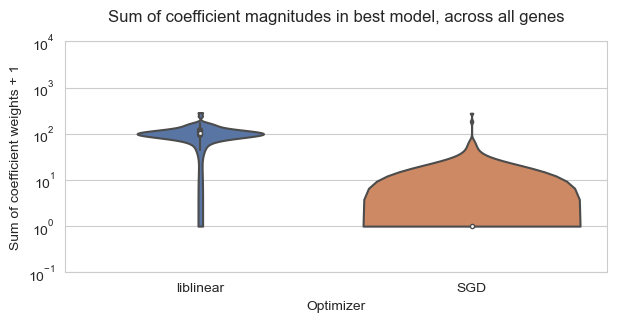

In [25]:
sns.set({'figure.figsize': (7, 3)})
sns.set_style('whitegrid')

coefs_perf_df = pd.concat((ll_coefs_perf_df, sgd_coefs_perf_df))
g = sns.violinplot(data=coefs_perf_df, x='optimizer', y='sum_coefs', cut=0)
g.set(yscale='log', ylim=(10e-2, 10e3))
plt.title('Sum of coefficient magnitudes in best model, across all genes', y=1.05)
plt.xlabel('Optimizer')
plt.ylabel('Sum of coefficient weights + 1')

if output_plots:
    plt.savefig(os.path.join(output_plots_dir, f'all_optimizers_coef_sum_dist_{lr_schedule}.svg'), bbox_inches='tight')

### Get difference between "best" and "largest" (least regularized) models

We can use this to determine how much a model overfits: that is, as model complexity increases, how much (or if at all) performance decreases from its peak.

In [26]:
def get_top_largest_diff(gene):
    # TODO: put some of repeated code in functions
    ll_top_lasso_param = ll_top_df.loc[gene, 'lasso_param']
    sgd_top_lasso_param = sgd_top_df.loc[gene, 'lasso_param']
    
    ll_mean_test_perf_df = (
        ll_perf_df[(ll_perf_df.gene == gene) &
                   (ll_perf_df.data_type == 'test') &
                   (ll_perf_df.signal == 'signal')]
          .groupby(['lasso_param'])
          .agg(np.mean)
          .drop(columns=['seed', 'fold'])
          .rename(columns={'auroc': 'mean_auroc', 'aupr': 'mean_aupr'})
    )
    sgd_mean_test_perf_df = (
        sgd_perf_df[(sgd_perf_df.gene == gene) &
                    (sgd_perf_df.data_type == 'test') &
                    (sgd_perf_df.signal == 'signal')]
          .groupby(['lasso_param'])
          .agg(np.mean)
          .drop(columns=['seed', 'fold'])
          .rename(columns={'auroc': 'mean_auroc', 'aupr': 'mean_aupr'})
    )
    
    # use maximum liblinear parameter = largest (least regularized) model
    ll_top_largest_diff = (
        ll_mean_test_perf_df.loc[ll_top_lasso_param, 'mean_aupr'] -
        ll_mean_test_perf_df.loc[ll_perf_df.lasso_param.max(), 'mean_aupr']
    )
    # use minimum SGD parameter = largest (least regularized) model
    sgd_top_largest_diff = (
        sgd_mean_test_perf_df.loc[sgd_top_lasso_param, 'mean_aupr'] -
        sgd_mean_test_perf_df.loc[sgd_perf_df.lasso_param.min(), 'mean_aupr']
    )
    
    return [gene,
            ll_top_lasso_param,
            sgd_top_lasso_param,
            ll_top_largest_diff,
            sgd_top_largest_diff]

print(get_top_largest_diff('PTEN'))

['PTEN', 1.0, 1.0, 0.0, 0.0]


In [27]:
all_top_largest_diff_df = []

for gene in ll_perf_df.gene.unique():
    all_top_largest_diff_df.append(
        get_top_largest_diff(gene)
    )
        
all_top_largest_diff_df = pd.DataFrame(
    all_top_largest_diff_df,
    columns=['gene',
             'll_top_lasso_param',
             'sgd_top_lasso_param',
             'll_top_largest_diff',
             'sgd_top_largest_diff']
)

all_top_largest_diff_df['largest_diff'] = 'liblinear'
all_top_largest_diff_df.loc[
    all_top_largest_diff_df.ll_top_largest_diff < all_top_largest_diff_df.sgd_top_largest_diff,
    'largest_diff'
] = 'SGD'
# this probably won't happen but just in case
all_top_largest_diff_df.loc[
    all_top_largest_diff_df.ll_top_largest_diff == all_top_largest_diff_df.sgd_top_largest_diff,
    'largest_diff'
] = 'equal'

print(all_top_largest_diff_df.largest_diff.value_counts())
all_top_largest_diff_df.head()

equal    50
Name: largest_diff, dtype: int64


,gene,ll_top_lasso_param,sgd_top_lasso_param,ll_top_largest_diff,sgd_top_largest_diff,largest_diff
0,ABCA13,1.0,1.0,0.0,0.0,equal
1,AHNAK2,1.0,1.0,0.0,0.0,equal
2,APC,1.0,1.0,0.0,0.0,equal
3,APOB,1.0,1.0,0.0,0.0,equal
4,ARID1A,1.0,1.0,0.0,0.0,equal


In [28]:
plot_df = (all_top_largest_diff_df
    .rename(columns={'ll_top_largest_diff': 'liblinear',
                     'sgd_top_largest_diff': 'SGD'})
    .melt(
        id_vars=['gene', 'll_top_lasso_param', 'sgd_top_lasso_param', 'largest_diff'],
        var_name='optimizer',
        value_name='top_largest_diff'
    )
)

plot_df.head()

,gene,ll_top_lasso_param,sgd_top_lasso_param,largest_diff,optimizer,top_largest_diff
0,ABCA13,1.0,1.0,equal,liblinear,0.0
1,AHNAK2,1.0,1.0,equal,liblinear,0.0
2,APC,1.0,1.0,equal,liblinear,0.0
3,APOB,1.0,1.0,equal,liblinear,0.0
4,ARID1A,1.0,1.0,equal,liblinear,0.0


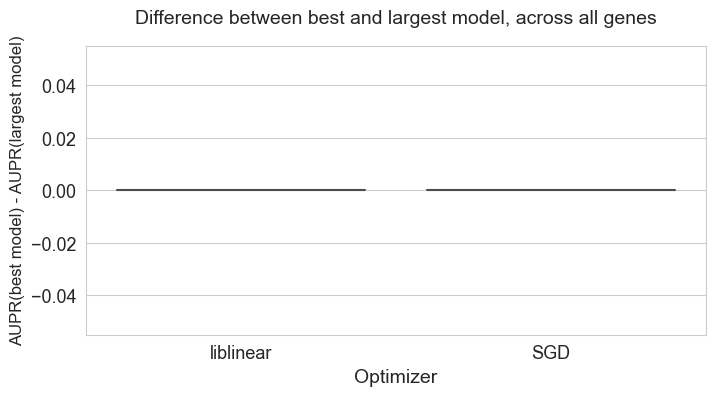

In [29]:
sns.set({'figure.figsize': (8, 3.75)})
sns.set_style('whitegrid')

sns.violinplot(data=plot_df, x='optimizer', y='top_largest_diff', cut=0)
plt.title('Difference between best and largest model, across all genes', y=1.05, size=14)
plt.xlabel('Optimizer', size=14)
plt.ylabel('AUPR(best model) - AUPR(largest model)', size=12)
plt.gca().tick_params(axis='both', labelsize=13)

if output_plots:
    plt.savefig(os.path.join(output_plots_dir, f'all_optimizers_best_vs_largest_{lr_schedule}.svg'), bbox_inches='tight')

In [30]:
# genes that overfit the most using liblinear
(all_top_largest_diff_df
  .sort_values(by='ll_top_largest_diff', ascending=False)
  .head(10)
)

,gene,ll_top_lasso_param,sgd_top_lasso_param,ll_top_largest_diff,sgd_top_largest_diff,largest_diff
0,ABCA13,1.0,1.0,0.0,0.0,equal
37,RYR1,1.0,1.0,0.0,0.0,equal
27,MUC16,1.0,1.0,0.0,0.0,equal
28,MUC17,1.0,1.0,0.0,0.0,equal
29,MUC5B,1.0,1.0,0.0,0.0,equal
30,NEB,1.0,1.0,0.0,0.0,equal
31,OBSCN,1.0,1.0,0.0,0.0,equal
32,PCDH15,1.0,1.0,0.0,0.0,equal
33,PCLO,1.0,1.0,0.0,0.0,equal
34,PIK3CA,1.0,1.0,0.0,0.0,equal


In [31]:
# genes that overfit the most using SGD
(all_top_largest_diff_df
  .sort_values(by='sgd_top_largest_diff', ascending=False)
  .head(10)
)

,gene,ll_top_lasso_param,sgd_top_lasso_param,ll_top_largest_diff,sgd_top_largest_diff,largest_diff
0,ABCA13,1.0,1.0,0.0,0.0,equal
37,RYR1,1.0,1.0,0.0,0.0,equal
27,MUC16,1.0,1.0,0.0,0.0,equal
28,MUC17,1.0,1.0,0.0,0.0,equal
29,MUC5B,1.0,1.0,0.0,0.0,equal
30,NEB,1.0,1.0,0.0,0.0,equal
31,OBSCN,1.0,1.0,0.0,0.0,equal
32,PCDH15,1.0,1.0,0.0,0.0,equal
33,PCLO,1.0,1.0,0.0,0.0,equal
34,PIK3CA,1.0,1.0,0.0,0.0,equal
